In [ ]:
import numpy as np
import jax.numpy as jnp
from jax.scipy.special import erfc, erf
import matplotlib.pyplot as plt
from log_normal_h2 import get_lnorms, get_h2_mean_var
from gwb import sample_compound, AstroPopulation
from scipy.special import logsumexp
from astropy.cosmology import WMAP9 as cosmo

# Phenomenological model

We can approximate the statistics of the characteristic strain $h^2_c$ using the saddlepoint approximation method. To do so, we need to define a model that gives the comoving number density of GW sources. We use the simple phenomelogical model from (cite)

# $\frac{d^2 n}{dz d\log \mathcal{M}} = \dot{n}_0 \frac{dt}{dz} \times \left ( \frac{\mathcal{M}}{10^7 M_\odot}\right )^{-\alpha} e^{-\mathcal{M} / \mathcal{M}_0} \times (1+z)^{\beta} e^{-z/z_0}$
This is the default model that is used by the code.

We initiate a set of values for the parameters of the model.

In [59]:
# constants, solar mass and year
m_sun = 1.989e30
c = 2.998e8
G = 6.674e-11
Mpc = 3.086e22
yr = 365.25 * 24 * 3600

# high mass model
alpha = 0.5
log10_m0 = 9.3
m0 = 10**log10_m0 * m_sun
beta = 0.5
z0 = 1.
log10_n0_dot = np.log10(1.26e-3)

# # model low mass
# alpha = 0.5
# log10_m0 = 8.3
# m0 = 10**log10_m0 * m_sun
# beta = 0.5
# z0 = 1.
# n0_dot = 1.8e-2

# set Tspan and frequencies
Tspan = 20 * yr
freqs = np.arange(1, 20) / Tspan

For this model we can also estimate the mean and variance of the expected characteristic strain $h^2_c$, which can be used for moment matching with some probability distributions (cite).

We also need to define a grid of $h^2_c$ values to plot the distribution.

In [60]:
# get mean and variance of h2c
h2c, var_h2c = get_h2_mean_var(freqs, 10**log10_n0_dot, alpha, m0, beta, z0)

# grid of h2c values
h2 = np.logspace(-36, -26, 5001)
dh2 = np.diff(h2)
h2 = h2[:-1]

# get moment matched log-normal distribution
lnorms = get_lnorms(h2, freqs, log10_n0_dot, alpha, m0, beta, z0)

/home/mfalxa/PTA/git/zamari/log_normal_h2.py:89: RuntimeWarning: invalid value encountered in log
  mu = np.log(mean) - 0.5 * np.log(1 + (var/mean**2))
/home/mfalxa/PTA/git/zamari/log_normal_h2.py:98: RuntimeWarning: invalid value encountered in scalar power
  lnorms = [lognorm.pdf(h2, s=sig2[n]**0.5, scale=np.exp(mu[n])) for n in range(len(freqs))]


We create an instance of the class `AstroPopulation` that takes as input the array of frequencies at which the probability distribution will be estimated `freqs` and the list of model parameter names `param_names`.

In [61]:
# set parameter dictionary
params = {'log10_n0_dot':log10_n0_dot, 'alpha':alpha, 'log10_m0':log10_m0, 'beta':beta, 'z0':z0}
param_names = [*params]

# get saddlepoint
astro = AstroPopulation(freqs, param_names)
lnpdfs = astro.lnpdf_vmap(h2, params)

The `astro.get_lnpdf` function will output an array of size `freqs x h2` that contains the set of probability distributions estimated on the grid `h2` at frequencies `freqs` for the set of model parameters `params`.

We write the following function for custom violin plots.

In [62]:
def plot_violin(x, pdf_x, position, width=1., color='C0', pmin=0.01, label=None):

    mask = pdf_x > pmin * np.amax(pdf_x)
    p = 0.5 * width * pdf_x / np.amax(pdf_x)
    plt.fill_betweenx(x[mask], position + p[mask], position - p[mask], alpha=0.2, color=color, label=label)

We plot the probability distributions with the expected ensemble average for this set of model parameters. Note that the average lies on the higher end of the probability distributions, because the average is dominated by the high $h^2_c$ tail of the distribution.

The model parameters are chosen so that $h_c = 3\times 10^{-15} \left ( f \times yr \right)^{-2/3}$.

We also plot the moment matched log-normal distribution to show the difference with the saddlepoint, even though the mean and variance are matched.

To plot $p(h_c)$ we need to perform a small change of variable from the estimated $p(h^2_c)$ as $p(h_c) = 2 |h_c| p(h_c^2)$.

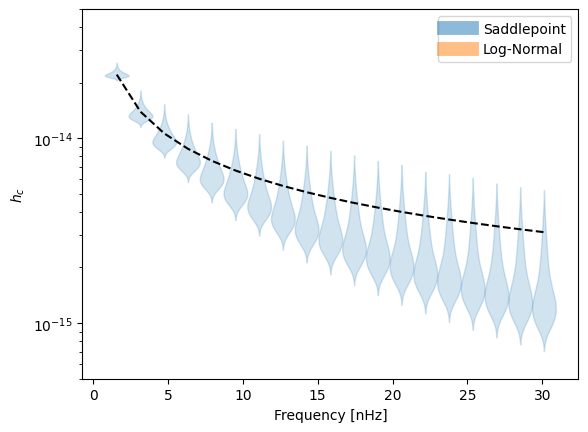

In [63]:
from matplotlib.lines import Line2D

# Ensemble average
plt.plot(freqs * 1e9, 3e-15 * (freqs * yr)**(-2/3), ls='--', c='k')

# Saddlepoint in BLUE
for n, pdf in enumerate(np.exp(lnpdfs)):
    plot_violin(h2**0.5, pdf * 2 * h2**0.5, freqs[n] * 1e9, width=freqs[0] * 1e9)

# Log-normal in ORANGE
for n, pdf in enumerate(lnorms):
    plot_violin(h2**0.5, pdf * 2 * h2**0.5, freqs[n] * 1e9, width=freqs[0] * 1e9, color='C1')

plt.yscale('log')
plt.ylabel('$h_c$')
plt.xlabel('Frequency [nHz]')
plt.ylim((5e-16, 5e-14))
handles = [
    Line2D([], [], color='C0', lw=10., alpha=0.5, label='Saddlepoint'),
    Line2D([], [], color='C1', lw=10., alpha=0.5, label='Log-Normal'),
]
plt.legend(handles=handles)
plt.show()

# Alternative models and parametrisations

The code is written to take as input any function $\frac{d^2 n}{dz d\log \mathcal{M}}$ with alternative parametrisations. Here, we use the mass function defined in [ref](https://arxiv.org/pdf/1906.05138).

This new parametrisation gives the mass function at $z=0$ as a function of the black hole seed initial mass function parameters and accretion parameters.
Any mass function can be used, ideally, outputs of more elaborate semi-analytical models.

We also change the frequency dependence of the signal adding a turnover at $f=1/(1yr)$.

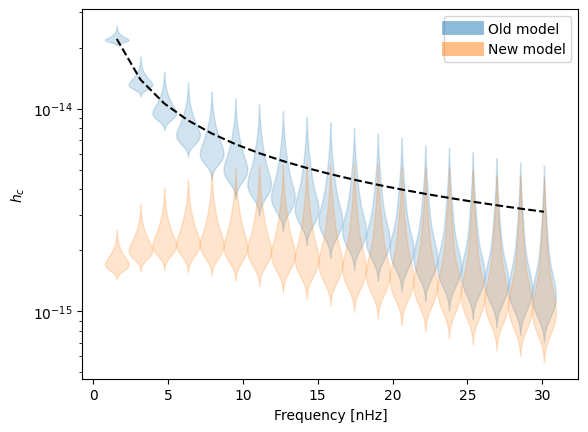

In [64]:
# defined model, the first three arguments must always be z, dt_dz, mc. The others are model parameters.
def d2n_dzdlog10M_new(z, dt_dz, mc, n0_dot, alpha, log10_m0, sig0, beta, z0, gamma):

    mc /= m_sun
    m0 = 10**log10_m0

    # astrophysics terms
    mass_term = 0.5 * (alpha * jnp.exp(alpha * m0 + 0.5 * alpha**2 * sig0**2) / (1 - jnp.exp(-alpha * beta))) * mc**(-alpha)
    mass_term *= (erf(2**(-0.5) * (alpha * sig0 - (jnp.log(mc) - m0 - beta) / sig0)) - erf(2**(-0.5) * (alpha * sig0 - (jnp.log(mc) - m0) / sig0)))
    redshift_term = z**gamma * jnp.exp(-z/z0) * dt_dz

    return n0_dot * mass_term * redshift_term

# change frequency dependence, now adding new parameter "f_index"
def df_dt_new(mc, f, f_index):

    return (96/5) * jnp.pi**(8/3) * (G * mc / c**3)**(5/3) * f**(11/3) * (1 + (f * yr)**f_index)

# define a set of parameters
params_new = {'n0_dot':5e-2, 'alpha':0.5, 'log10_m0':1.04, 'sig0':0.75, 'beta':10, 'z0':1., 'gamma':0.5, 'f_index':-2}

# create astro population instance with the new model given through the argument d2n_dzdlog10M
astro_new = AstroPopulation(freqs, [*params_new], d2n_dzdlog10M=d2n_dzdlog10M_new, dfdt=df_dt_new)
lnpdfs_new = astro_new.lnpdf_vmap(jnp.array(h2), params_new)

# overplot old and new models
plt.plot(freqs * 1e9, 3e-15 * (freqs * yr)**(-2/3), ls='--', c='k')
for n, pdf in enumerate(np.exp(lnpdfs)):
    plot_violin(h2**0.5, pdf * 2 * h2**0.5, freqs[n] * 1e9, width=freqs[0] * 1e9, color='C0')

for n, pdf in enumerate(np.exp(lnpdfs_new)):
    plot_violin(h2**0.5, pdf * 2 * h2**0.5, freqs[n] * 1e9, width=freqs[0] * 1e9, color='C1')
plt.yscale('log')
plt.ylabel('$h_c$')
plt.xlabel('Frequency [nHz]')
handles = [
    Line2D([], [], color='C0', lw=10., alpha=0.5, label='Old model'),
    Line2D([], [], color='C1', lw=10., alpha=0.5, label='New model'),
]
plt.legend(handles=handles)
plt.show()


# Semi-Analytical model output

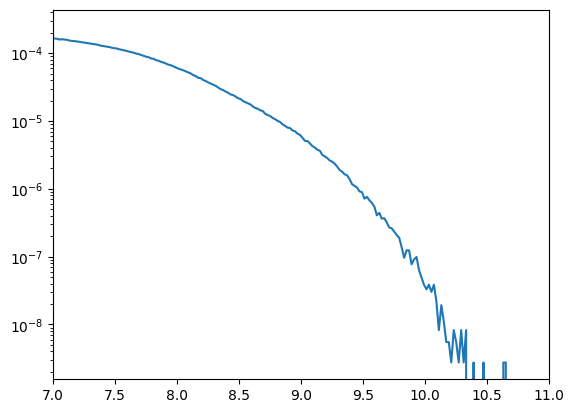

AAAAAfffffff 2.1373887493636733e-15
(500, 936)
500 936


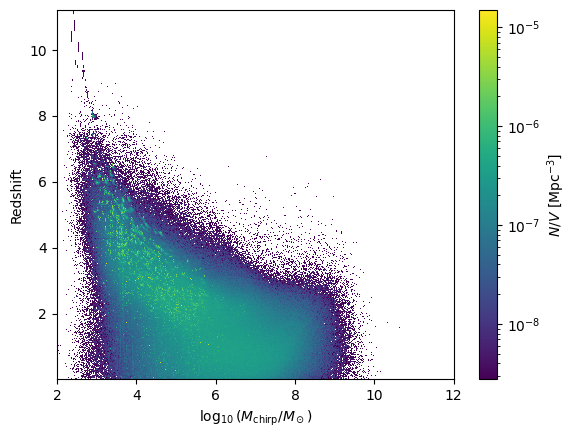

[0.01       0.01127304 0.01270815 0.01432596 0.01614971 0.01820564
 0.0205233  0.02313601 0.02608132 0.02940159 0.03314454 0.03736399
 0.04212059 0.04748272 0.05352748 0.06034176 0.06802353 0.07668323
 0.08644534 0.09745021 0.10985605 0.12384121 0.13960674 0.1573793
 0.17741437 0.2        0.22546088 0.25416304 0.28651911 0.32299425
 0.36411284 0.41046601 0.46272013 0.52162644 0.58803177 0.6628908
 0.74727972 0.84241171 0.94965442 1.0705496  1.20683527 1.3604707
 1.5336646  1.72890684 1.94900428 2.19712109 2.47682426 2.79213487
 3.1475859  3.54828742]
[37.29863478 37.38026744 37.46190009 37.54353274 37.6251654  37.70679805
 37.7884307  37.87006335 37.95169601 38.03332866 38.11496131 38.19659397
 38.27822662 38.35985927 38.44149193 38.52312458 38.60475723 38.68638989
 38.76802254 38.84965519 38.93128784 39.0129205  39.09455315 39.1761858
 39.25781846 39.33945111 39.42108376 39.50271642 39.58434907 39.66598172
 39.74761437 39.82924703 39.91087968 39.99251233 40.07414499 40.15577764
 40.23

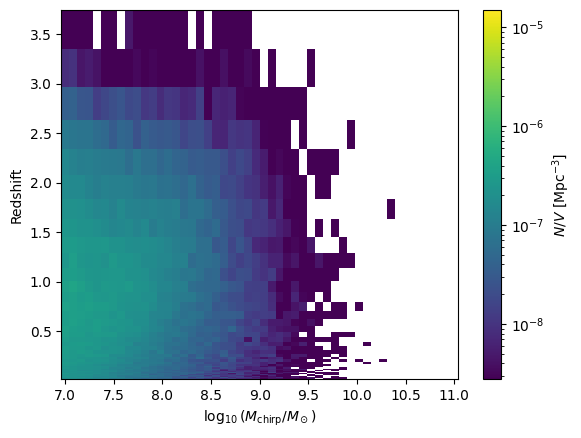

SHAPE (50, 50)
(19, 5000)


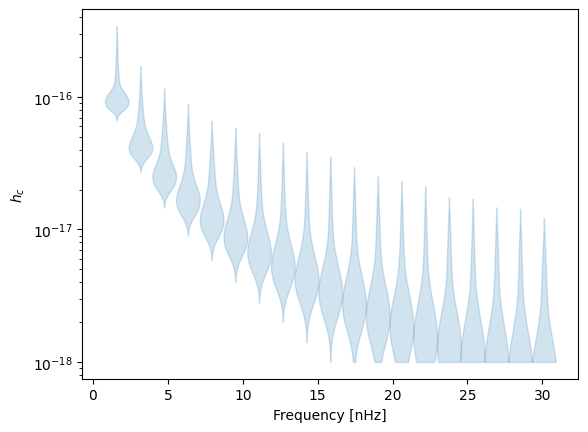

In [ ]:
from scipy.interpolate import interp2d
from matplotlib.colors import LogNorm
from scipy.interpolate import RegularGridInterpolator


data = np.loadtxt('data/Mchirp_Redshift_SuperEdd_Model(1)',  skiprows=1)
# data = np.loadtxt('data/Mchirp_Redshift_Eddington-HeavyMax_Model')
logM = data[:, 0]
z = data[:, 1]
density = data[:, 2]
logM_values = np.unique(logM) + np.log10(m_sun)
z_values = np.unique(z)
H = density.reshape(len(logM_values), len(z_values))

dz = np.gradient(z_values)
plt.semilogy(np.unique(logM), np.sum(H * dz[None, :], axis=1))
plt.xlim((7, 11))
plt.show()


Mpc_to_km =  3.1e19
G = 43.001
c_Km_s = 3e5
fref = 1 /  3.15e7

logM_centers = data[:, 0]
z_centers    = data[:, 1]
H_density    = data[:, 2]
M_chirp_1e10 = 10**logM_centers / 1e10
integrand = (H_density * (G * M_chirp_1e10)**(5./3.) / (1. + z_centers)**(1./3.))
A = np.sum(integrand)
A_f = np.sqrt( Mpc_to_km**(-4./3.)  * 4.0 * np.pi  * (3.0 * c_Km_s**2.0)**(-1.0) * (np.pi * fref)**(-4./3.)  * A)

print('AAAAAfffffff', A_f)

print(np.shape(H))
print(len(logM_values), len(z_values))
plt.pcolormesh(logM_values - np.log10(m_sun), z_values, H.T, shading="auto", norm=LogNorm(vmin=density[density > 0].min(), vmax=density.max()))

plt.xlabel(r"$\log_{10}(M_{\rm chirp}/M_\odot)$")
plt.ylabel("Redshift")
plt.colorbar(label=r"$N/V\ [{\rm Mpc}^{-3}]$")
plt.show()
# n2d = interp2d(logM, z, H)

interp = RegularGridInterpolator(
    (z_values, logM_values),
    H.T,
    method="linear",
    bounds_error=False,
    fill_value=np.nan,
)

X_new, Y_new = np.meshgrid(astro_new.log10_mc, astro_new.z)
points = np.column_stack((Y_new.ravel(), X_new.ravel()))

# points = np.column_stack((astro_new.z, astro_new.log10_mc))
print(astro_new.z)
print(astro_new.log10_mc)

H_new = interp(points).reshape(len(X_new), len(Y_new))
plt.pcolormesh(astro_new.log10_mc - np.log10(m_sun), astro_new.z, H_new, shading="auto", norm=LogNorm(vmin=density[density > 0].min(), vmax=density.max()))

plt.xlabel(r"$\log_{10}(M_{\rm chirp}/M_\odot)$")
plt.ylabel("Redshift")
plt.colorbar(label=r"$N/V\ [{\rm Mpc}^{-3}]$")
plt.show()

H_new = jnp.array(H_new)
n2d = lambda z, dt_dz, mc, A : A * H_new

print('SHAPE', jnp.shape(n2d(astro_new.z[:, None], astro_new.dt_dz, 10**astro_new.z[None, :], 1.)))


# grid of h2c values
h2 = np.logspace(-36, -26, 5001)
dh2 = np.diff(h2)
h2 = h2[:-1]

params_new = {'A':1.}
astro_new = AstroPopulation(freqs, [*params_new], d2n_dzdlog10M=n2d)
lnpdfs_new = astro_new.lnpdf_vmap(jnp.array(h2), params_new)

print(np.shape(lnpdfs_new))

plt.cla()
plt.clf()

for n, pdf in enumerate(np.exp(lnpdfs_new)):
    plot_violin(h2**0.5, pdf * 2 * h2**0.5, freqs[n] * 1e9, width=freqs[0] * 1e9, color='C0')
plt.yscale('log')
plt.ylabel('$h_c$')
plt.xlabel('Frequency [nHz]')
plt.show()

